In [1]:
import numpy as np
import astropy.units as u
import astropy.constants as consts
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt
import h5py # python library to interact with hdf5 files
%matplotlib inline

# Exercise set 1: Load the snapshot from a cosmological hydrodynamic simulation

### Load the simulation output: HDF5 format file

In [2]:
# Load the simulation data
f = h5py.File('simulation256_z4.hdf5', 'r')

# show the available keys ['Data', 'Header']
print(f.keys())

# show the attributes in the header ['BoxSize', 'HubbleParam', 'OmegaB0', 'OmegaL0', 'OmegaM0', 'Redshift']
print(f['Header'].attrs.keys()) 
redshift = f['Header'].attrs['Redshift']    # redshift
boxsize  = f['Header'].attrs['BoxSize']     # box size [cMpc/h]
h        = f['Header'].attrs['HubbleParam'] # dimensionless hubble parameter
OmegaM0  = f['Header'].attrs['OmegaM0']     # matter density parameter
OmegaL0  = f['Header'].attrs['OmegaL0']     # dark energy density parameter
OmegaB0  = f['Header'].attrs['OmegaB0']     # baryon density parameter
print(f"Redshift: {redshift}, BoxSize: {boxsize}, h: {h}, OmegaM0: {OmegaM0}, OmegaL0: {OmegaL0}, OmegaB0: {OmegaB0}")

# show the available keys in Data ['rho_m', 'rho_b'] 
print(f['Data'].keys())

# Keep the data as 3D numpy arrays
rho_m = f['Data']['rho_m']*u.g*u.cm**-3
rho_b = f['Data']['rho_b']*u.g*u.cm**-3

Y=0.24 # Helium mass fraction
nH = (1-Y)*rho_b/(consts.m_p) # number density of hydrogen atoms

# Define the cosmology
cosmo = FlatLambdaCDM(H0=100*h*u.km/u.s/u.Mpc, Om0=OmegaM0, Ob0=OmegaB0)


<KeysViewHDF5 ['Data', 'Header']>
<KeysViewHDF5 ['BoxSize', 'HubbleParam', 'OmegaB0', 'OmegaL0', 'OmegaM0', 'Redshift']>
Redshift: 3.997217447420394, BoxSize: 39.92636424120911, h: 0.6773999786376951, OmegaM0: 0.308899998664856, OmegaL0: 0.691100001335144, OmegaB0: 0.045
<KeysViewHDF5 ['rho_b', 'rho_m']>


### Plot 2D slice of the density field

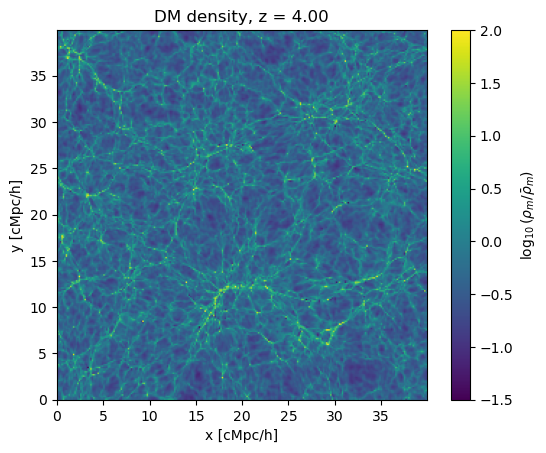

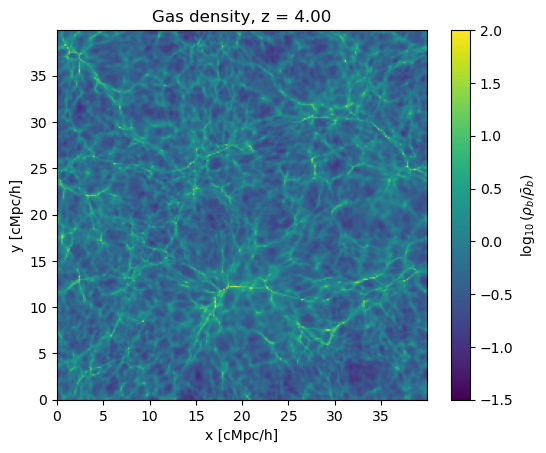

In [3]:
# Plot the dark matter density in a slice
plt.figure()
Delta_m = rho_m[:,:,:]/rho_m.mean()
plt.imshow(np.log10(Delta_m[:,:,128]),extent=[0,boxsize,0,boxsize],
           origin='lower',vmin=-1.5,vmax=2)
plt.title('DM density, z = %.2f'%redshift)
plt.colorbar(label=r'$\log_{10}(\rho_m/\bar{\rho}_m)$')
plt.xlabel('x [cMpc/h]')
plt.ylabel('y [cMpc/h]')

# Plot the gas density in a slice
plt.figure()
Delta_b = rho_b[:,:,:]/rho_b.mean()
plt.imshow(np.log10(Delta_b[:,:,128]),extent=[0,boxsize,0,boxsize],
           origin='lower',vmin=-1.5,vmax=2)
plt.title('Gas density, z = %.2f'%redshift)
plt.colorbar(label=r'$\log_{10}(\rho_b/\bar{\rho}_b)$')
plt.xlabel('x [cMpc/h]')
plt.ylabel('y [cMpc/h]')
plt.show()

### Plot the 1D skewers

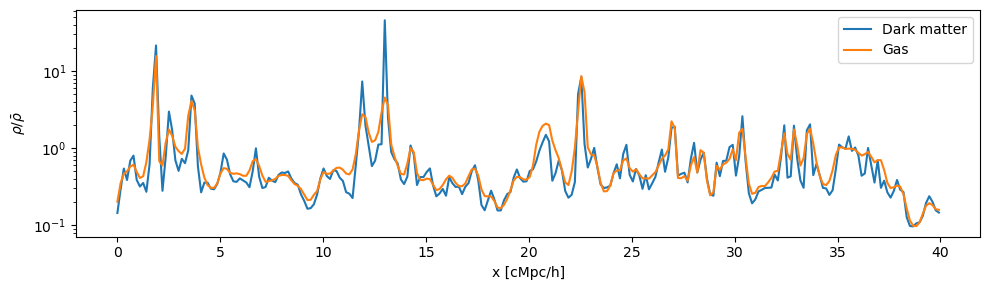

In [4]:
# Plot the 1D skewers
plt.figure(figsize=(10,3))
x = np.linspace(0,boxsize,256)
plt.plot(x,Delta_m[128,128,:],label='Dark matter')
plt.plot(x,Delta_b[128,128,:],label='Gas')
#plt.plot(x,Delta[10,128,:])
#plt.plot(x,Delta[128,10,:])
plt.yscale('log')
plt.xlabel('x [cMpc/h]')
plt.ylabel(r'$\rho/\bar{\rho}$')
plt.legend()
plt.tight_layout()
plt.show()


# Exercise set 2: Lyman-α Forest and Gunn–Peterson Optical Depth

## Exercise 2.1 — Generate a Simulated Lyman-α Forest Spectrum

Using the gas density output from the cosmological simulation, we compute the transmitted flux

\[
F(\lambda) = e^{-\tau_{\alpha}^{GP}}
\]

using the fluctuating Gunn–Peterson approximation.

Steps:
1. Extract a skewer (line of sight) through the simulation box.
2. Convert gas density to hydrogen number density.
3. Assume a trial neutral hydrogen fraction \(x_{HI}\).
4. Compute the Gunn–Peterson optical depth.
5. Convert simulation position to observed wavelength.
6. Generate the transmitted flux spectrum.

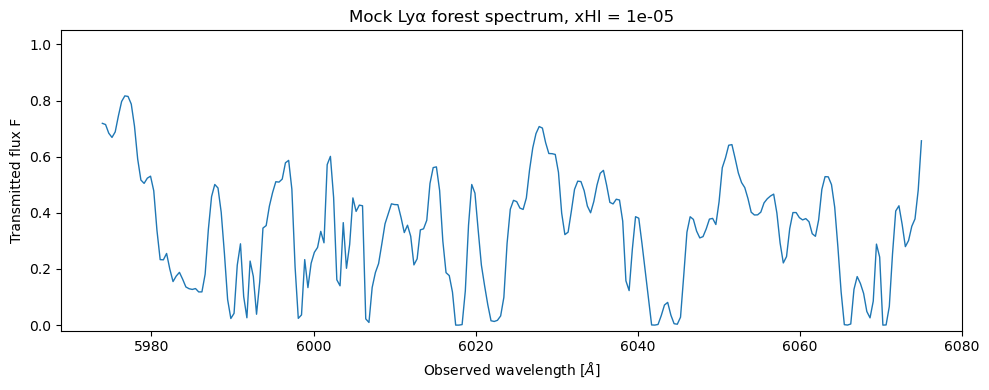

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from astropy.cosmology import FlatLambdaCDM

# -------------------------
# Constants and cosmology
# -------------------------
Y = 0.24                                  # helium mass fraction
lambda_alpha = 1215.67 * u.AA             # Ly-alpha wavelength
nu_alpha = (const.c / lambda_alpha).to(u.Hz)
sigma_alpha = 0.011 * u.cm**2 * u.Hz      # given in the sheet

cosmo = FlatLambdaCDM(H0=100*h*u.km/u.s/u.Mpc, Om0=OmegaM0, Ob0=OmegaB0)
Hz = cosmo.H(redshift).to(u.s**-1)

# -------------------------
# Pick one skewer
# -------------------------
ix, iy = 128, 128
rho_b_skewer = rho_b[ix, iy, :]           # along z-axis

# hydrogen number density
nH_skewer = ((1 - Y) * rho_b_skewer / const.m_p).to(u.cm**-3)

# -------------------------
# Choose a trial neutral fraction
# -------------------------
xHI = 1e-5

# neutral hydrogen density
nHI_skewer = xHI * nH_skewer

# Gunn-Peterson optical depth
tau_gp = ((sigma_alpha * const.c * nHI_skewer) / (nu_alpha * Hz)).decompose().value

# transmitted flux
F = np.exp(-tau_gp)

# -------------------------
# Convert box position to redshift and wavelength
# -------------------------
N = rho_b.shape[2]
dx = (boxsize / N) * (u.Mpc / h)          # comoving cell size
x_comoving = np.arange(N) * dx            # comoving position from near side

# convert H(z) to km/s/Mpc for use with c in km/s
Hz_km = cosmo.H(redshift).to(u.km/u.s/u.Mpc)
c_km = const.c.to(u.km/u.s)

# z_i = z_sim - H(z_sim) x_i / c
z_i = redshift - (Hz_km * x_comoving / c_km).decompose().value

# observed wavelength
lambda_obs = (lambda_alpha * (1 + z_i)).to(u.AA).value

# -------------------------
# Plot the mock spectrum
# -------------------------
plt.figure(figsize=(10,4))
plt.plot(lambda_obs, F, lw=1)
plt.xlabel(r'Observed wavelength [$\AA$]')
plt.ylabel('Transmitted flux F')
plt.title(f'Mock Lyα forest spectrum, xHI = {xHI:.0e}')
plt.ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

### Exercise 2.2 — Effect of Neutral Hydrogen Fraction & Comparison with Observed GRB Lyα Forest


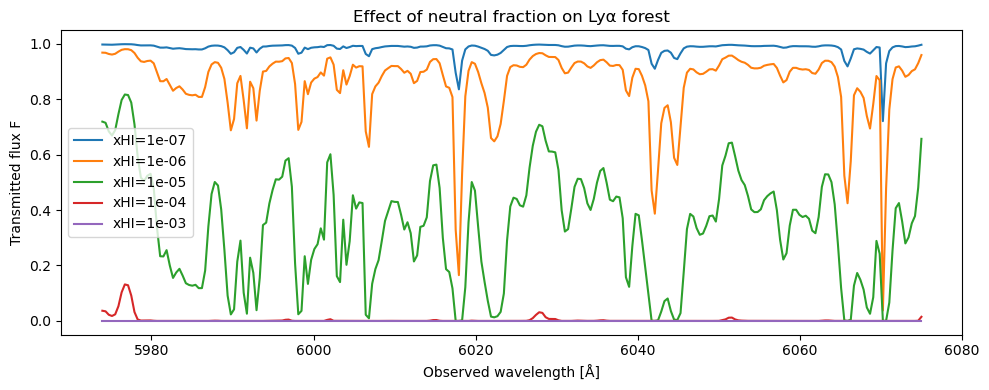

In [6]:
xHI_values = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3]

plt.figure(figsize=(10,4))

for xHI in xHI_values:
    
    nHI_skewer = xHI * nH_skewer
    tau_gp = ((sigma_alpha * const.c * nHI_skewer) / (nu_alpha * Hz)).decompose().value
    F = np.exp(-tau_gp)
    
    plt.plot(lambda_obs, F, label=f'xHI={xHI:.0e}')

plt.xlabel('Observed wavelength [Å]')
plt.ylabel('Transmitted flux F')
plt.title('Effect of neutral fraction on Lyα forest')
plt.legend()
plt.tight_layout()
plt.show()

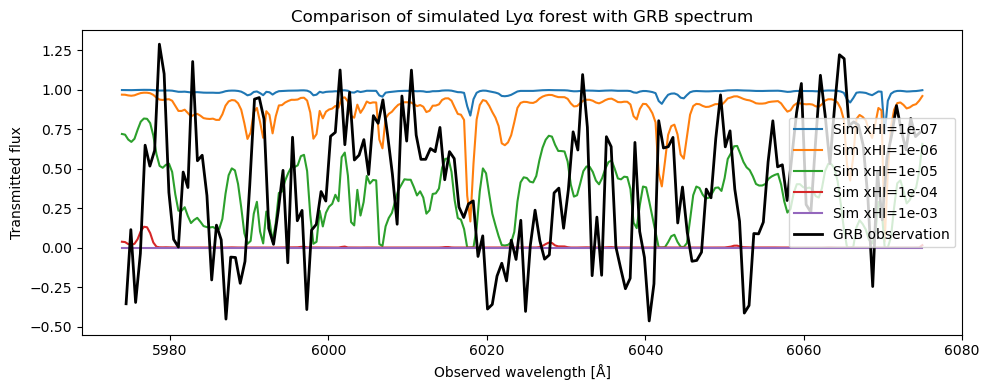

In [8]:
# Load GRB spectrum
data = np.loadtxt('norm100219A_vis.data')

lambda_grb = data[:,0]   # wavelength [Å]
flux_grb   = data[:,1]   # normalized flux

plt.figure(figsize=(10,4))

# plot simulated spectra
for xHI in xHI_values:
    
    nHI_skewer = xHI * nH_skewer
    tau_gp = ((sigma_alpha * const.c * nHI_skewer) / (nu_alpha * Hz)).decompose().value
    F = np.exp(-tau_gp)

    plt.plot(lambda_obs, F, label=f'Sim xHI={xHI:.0e}')

# restrict GRB spectrum to same wavelength range
mask = (lambda_grb > lambda_obs.min()) & (lambda_grb < lambda_obs.max())

plt.plot(lambda_grb[mask], flux_grb[mask],
         color='black', lw=2, label='GRB observation')

plt.xlabel('Observed wavelength [Å]')
plt.ylabel('Transmitted flux')
plt.title('Comparison of simulated Lyα forest with GRB spectrum')
plt.legend()
plt.tight_layout()
plt.show()

## Exercise Set 3 — Estimating the Hydrogen Photoionization Rate

We estimate the hydrogen photoionization rate \( \Gamma_{\rm HI} \) required to produce the observed Lyα forest absorption at \( z \approx 4 \).

## Exercise Set 3.1 — Redshift Evolution of the Mean Lyα Forest Optical Depth

We compare the observed redshift evolution of the mean Lyα forest transmission with simple Gunn–Peterson models, first including only cosmological expansion and then including photoionization equilibrium with constant \( \Gamma_{\rm HI} \).

In [9]:
songaila = np.loadtxt('songaila.data')
print(songaila.shape)
print(songaila[:5])

(60, 4)
[[2.4   0.82  0.9   0.71 ]
 [2.46  0.809 0.879 0.735]
 [2.54  0.818 0.899 0.761]
 [2.61  0.778 0.833 0.7  ]
 [2.67  0.728 0.839 0.608]]


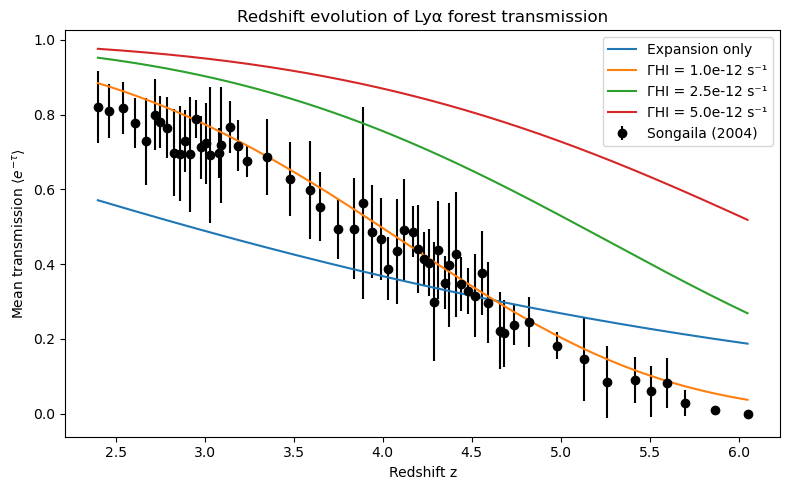

In [10]:
z_song = songaila[:,0]
F_song = songaila[:,1]

F_upper = songaila[:,2]
F_lower = songaila[:,3]

# symmetric error estimate
F_err = 0.5*(F_upper - F_lower)

z_grid = np.linspace(z_song.min(), z_song.max(), 400)

z0 = 4
tau0 = 1

tau_expansion = tau0 * ((1 + z_grid)/(1 + z0))**1.5
F_expansion = np.exp(-tau_expansion)

Gamma_values = [1e-12, 2.5e-12, 5e-12]  # s^-1

def tau_model(z, Gamma):
    
    return (
        0.7
        * (Gamma/1e-12)**(-1)
        * ((1+z)/5)**4.5
    )
    
F_models = {}

for Gamma in Gamma_values:
    
    tau = tau_model(z_grid, Gamma)
    F_models[Gamma] = np.exp(-tau)
    
plt.figure(figsize=(8,5))

# Songaila data
plt.errorbar(
    z_song, F_song,
    yerr=F_err,
    fmt='ko',
    label='Songaila (2004)'
)

# expansion-only model
plt.plot(
    z_grid,
    F_expansion,
    label='Expansion only'
)

# photoionization models
for Gamma in Gamma_values:
    
    plt.plot(
        z_grid,
        F_models[Gamma],
        label=f'ΓHI = {Gamma:.1e} s⁻¹'
    )

plt.xlabel('Redshift z')
plt.ylabel(r'Mean transmission $\langle e^{-\tau}\rangle$')
plt.title('Redshift evolution of Lyα forest transmission')
plt.legend()
plt.tight_layout()
plt.show()

## Exercise Set 3.2 — Fit the Photoionization Rate \( \Gamma_{\rm HI} \) from the GRB Mean Transmission

We estimate the hydrogen photoionization rate by matching the simulated mean Lyα forest transmission to the observed mean transmission of the GRB spectrum in the wavelength range \(6008\text{--}6077\) Å.

Observed mean transmission = 0.37735008695652167
Observed error on mean     = 0.037973319600172396
Number of GRB pixels       = 115
Best-fit Gamma_HI = 5.67242606849199e-13 s^-1
Best-fit simulated mean flux = 0.37794727789827737
Minimum chi^2 = 0.00024732572701066175


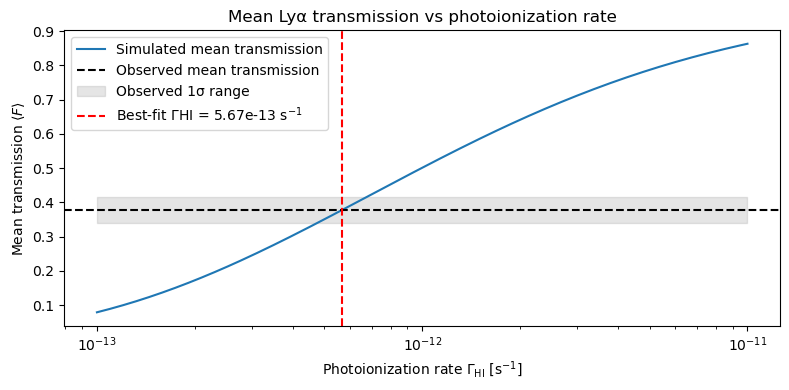

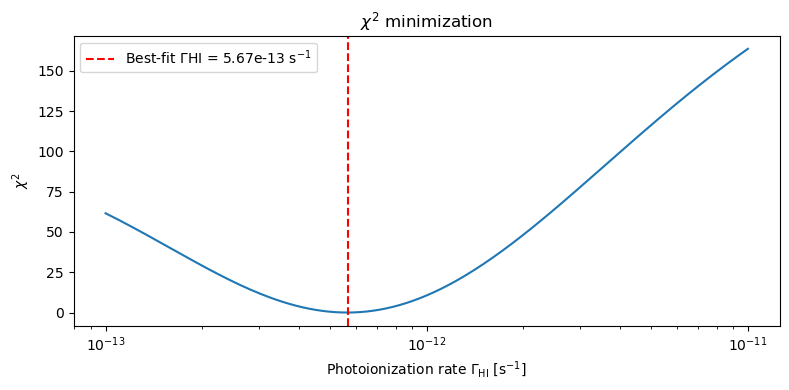

In [11]:
# wavelength window from the assignment
lam_min = 6008
lam_max = 6077

mask_grb = (lambda_grb >= lam_min) & (lambda_grb <= lam_max)

lambda_grb_win = lambda_grb[mask_grb]
flux_grb_win   = flux_grb[mask_grb]

F_obs_mean = np.mean(flux_grb_win)
sigma_obs  = np.std(flux_grb_win, ddof=1) / np.sqrt(len(flux_grb_win))

print("Observed mean transmission =", F_obs_mean)
print("Observed error on mean     =", sigma_obs)
print("Number of GRB pixels       =", len(flux_grb_win))

# constants
alphaA = 4.2e-13 * u.cm**3 / u.s      # recombination coefficient at T=1e4 K
sigma_alpha = 0.011 * u.cm**2 * u.Hz
lambda_alpha = 1215.67 * u.AA
nu_alpha = (const.c / lambda_alpha).to(u.Hz)

Hz = cosmo.H(redshift).to(1/u.s)

# hydrogen number density in every cell
nH_3d = ((1 - Y) * rho_b / const.m_p).to(u.cm**-3)

def mean_flux_simulated(Gamma_HI):
    """
    Compute the mean Lyα forest transmission in the box
    for a given photoionization rate Gamma_HI [s^-1].
    """
    Gamma = Gamma_HI / u.s

    # photoionization equilibrium: n_HI = alpha_A * n_H^2 / Gamma
    nHI_3d = alphaA * nH_3d**2 / Gamma

    # FGPA optical depth
    tau_3d = ((sigma_alpha * const.c * nHI_3d) / (nu_alpha * Hz)).decompose().value

    # transmitted flux
    F_3d = np.exp(-tau_3d)

    # convert z-axis cells to observed wavelength
    N = rho_b.shape[2]
    dx = (boxsize / N) * (u.Mpc / h)
    x_comoving = np.arange(N) * dx

    Hz_km = cosmo.H(redshift).to(u.km/u.s/u.Mpc)
    c_km = const.c.to(u.km/u.s)

    z_i = redshift - (Hz_km * x_comoving / c_km).decompose().value
    lambda_obs_sim = (lambda_alpha * (1 + z_i)).to(u.AA).value

    # wavelength window
    mask_sim = (lambda_obs_sim >= lam_min) & (lambda_obs_sim <= lam_max)

    # average over all skewers and selected wavelength pixels
    return F_3d[:, :, mask_sim].mean()

Gamma_grid = np.logspace(-13, -11, 200)   # s^-1

F_sim_grid = []
chi2_grid = []

for Gamma in Gamma_grid:
    F_sim = mean_flux_simulated(Gamma)
    chi2 = ((F_sim - F_obs_mean) / sigma_obs)**2

    F_sim_grid.append(F_sim)
    chi2_grid.append(chi2)

F_sim_grid = np.array(F_sim_grid)
chi2_grid  = np.array(chi2_grid)

best_idx = np.argmin(chi2_grid)

Gamma_best = Gamma_grid[best_idx]
F_best = F_sim_grid[best_idx]
chi2_best = chi2_grid[best_idx]

print("Best-fit Gamma_HI =", Gamma_best, "s^-1")
print("Best-fit simulated mean flux =", F_best)
print("Minimum chi^2 =", chi2_best)

plt.figure(figsize=(8,4))
plt.semilogx(Gamma_grid, F_sim_grid, label='Simulated mean transmission')
plt.axhline(F_obs_mean, color='k', ls='--', label='Observed mean transmission')
plt.fill_between(
    Gamma_grid,
    F_obs_mean - sigma_obs,
    F_obs_mean + sigma_obs,
    color='gray',
    alpha=0.2,
    label='Observed 1σ range'
)
plt.axvline(Gamma_best, color='r', ls='--', label=f'Best-fit ΓHI = {Gamma_best:.2e} s$^{{-1}}$')
plt.xlabel(r'Photoionization rate $\Gamma_{\rm HI}$ [s$^{-1}$]')
plt.ylabel(r'Mean transmission $\langle F\rangle$')
plt.title('Mean Lyα transmission vs photoionization rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.semilogx(Gamma_grid, chi2_grid)
plt.axvline(Gamma_best, color='r', ls='--', label=f'Best-fit ΓHI = {Gamma_best:.2e} s$^{{-1}}$')
plt.xlabel(r'Photoionization rate $\Gamma_{\rm HI}$ [s$^{-1}$]')
plt.ylabel(r'$\chi^2$')
plt.title(r'$\chi^2$ minimization')
plt.legend()
plt.tight_layout()
plt.show()

## Exercise Set 4 — Photoionization Rate from the Galaxy UV Luminosity Function

We model the hydrogen photoionization rate produced by galaxies using the observed UV luminosity function and compare it to the value inferred from the Lyα forest.

## 4.1 and 4.2

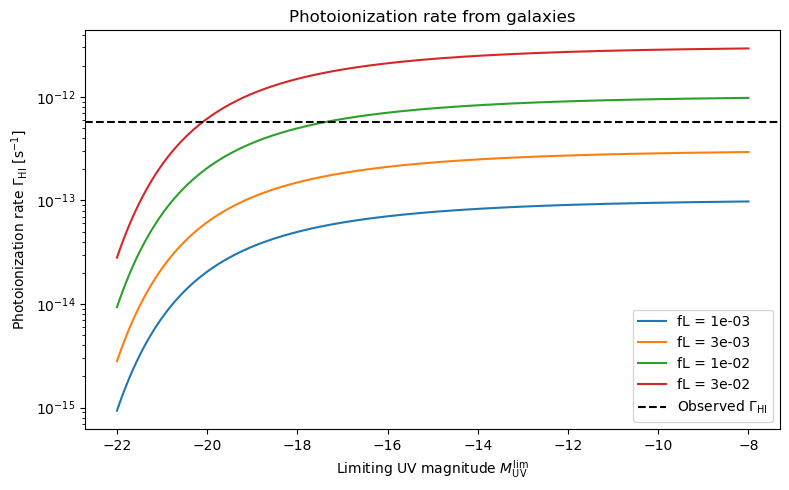

Required fL for MUV < -15: 0.007321758592219836


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parameters from the sheet
# -------------------------
phi_star = 1.46e-3     # cMpc^-3
M_star   = -20.95
alpha    = -1.72

z = 4.0
lambda_mfp = 100.0     # Mpc
alpha_s = 3.0

# cgs constants
sigma_L = 6.3e-18      # cm^2
h_p     = 6.62607015e-27   # erg s
pc_cm   = 3.085677581e18
Mpc_cm  = 3.085677581e24

def phi_M(M):
    """Schechter UV luminosity function in magnitude form."""
    return (
        (np.log(10)/2.5) * phi_star
        * 10**(-0.4*(M - M_star)*(alpha + 1))
        * np.exp(-10**(-0.4*(M - M_star)))
    )   # cMpc^-3 mag^-1

def Lnu_from_M(M):
    """AB magnitude -> specific luminosity L_nu in erg/s/Hz."""
    return 4 * np.pi * (10 * pc_cm)**2 * 10**(-0.4 * (M + 48.6))

def emissivity_uv(Mlim):
    """
    Proper UV emissivity at 1500 Å:
    epsilon_UV = (1+z)^3 ∫ L_nu(M) Phi(M) dM
    """
    M_grid = np.linspace(-30, Mlim, 20000)  # bright -> faint
    integrand = Lnu_from_M(M_grid) * phi_M(M_grid)   # erg/s/Hz/cMpc^3/mag
    integral = np.trapezoid(integrand, M_grid)       # erg/s/Hz/cMpc^3

    # convert comoving Mpc^-3 -> proper cm^-3
    epsilon_uv = (1 + z)**3 * integral / (Mpc_cm**3)
    return epsilon_uv   # erg/s/Hz/cm^3

def Gamma_HI_galaxies(Mlim, fL):
    """
    Photoionization rate from galaxies.
    """
    epsilon_uv = emissivity_uv(Mlim)
    epsilon_L = fL * epsilon_uv

    Gamma = sigma_L * (lambda_mfp * Mpc_cm) * epsilon_L / (h_p * (alpha_s + 3))
    return Gamma   # s^-1

Mlim_grid = np.linspace(-22, -8, 200)
fL_values = [1e-3, 3e-3, 1e-2, 3e-2]

plt.figure(figsize=(8,5))

for fL in fL_values:
    Gamma_vals = [Gamma_HI_galaxies(Mlim, fL) for Mlim in Mlim_grid]
    plt.plot(Mlim_grid, Gamma_vals, label=f'fL = {fL:.0e}')

# your measured value from Exercise 3.2
Gamma_obs = 5.67242606849199e-13
plt.axhline(Gamma_obs, color='k', ls='--', label=r'Observed $\Gamma_{\rm HI}$')

plt.xlabel(r'Limiting UV magnitude $M_{\rm UV}^{\rm lim}$')
plt.ylabel(r'Photoionization rate $\Gamma_{\rm HI}$ [s$^{-1}$]')
plt.title('Photoionization rate from galaxies')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

Gamma_unit = Gamma_HI_galaxies(-15, 1.0)   # value for fL = 1
fL_needed_M15 = Gamma_obs / Gamma_unit

print("Required fL for MUV < -15:", fL_needed_M15)



## 4.3

In [14]:
# intrinsic fL from a blackbody stellar spectrum

h_cgs = 6.62607015e-27      # erg s
c_cgs = 2.99792458e10       # cm s^-1
k_cgs = 1.380649e-16        # erg K^-1

def B_nu_lambda(lambda_A, T):
    lam_cm = lambda_A * 1e-8
    nu = c_cgs / lam_cm
    return (2*h_cgs*nu**3 / c_cgs**2) / (np.exp(h_cgs*nu/(k_cgs*T)) - 1)

T_star = 30000.0  # K

fL_intr = B_nu_lambda(912.0, T_star) / B_nu_lambda(1500.0, T_star)

print("Intrinsic fL for T = 30000 K:", fL_intr)

# required fL for galaxies brighter than MUV < -10
Gamma_unit_M10 = Gamma_HI_galaxies(-10, 1.0)
fL_needed_M10 = Gamma_obs / Gamma_unit_M10

# escape fraction
fesc_needed = fL_needed_M10 / fL_intr

print("Required fL for MUV < -10:", fL_needed_M10)
print("Required fesc:", fesc_needed)

Intrinsic fL for T = 30000 K: 0.5459758647056929
Required fL for MUV < -10: 0.005964128698756083
Required fesc: 0.010923795508746588
